# Time integration

Integrate the LLG equation in real time with the single-layer RK4 stepper: first a damped precession in an applied field, then a skyrmion driven by spin-orbit torque. No demag.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyrmion_simulator.simulator.params_helper import make_params
from skyrmion_simulator.simulator.pulses import ConstantPulse
mu0 = 4.0e-7 * np.pi
from skyrmion_simulator.simulator.fields import effective_field
from skyrmion_simulator.simulator.integrator import llgs_rhs, rk4_step_single
from skyrmion_simulator.simulator.relaxation import relax
from skyrmion_simulator.simulator.initial_conditions import skyrmion_profile
from skyrmion_simulator.stochastic_llgs.diagnostics import skyrmion_center_pbc


def rhs(m, p, t):
    """Single-layer LLGS right-hand side without demag."""
    H = effective_field(m, None, p.C_ex, p.C_dmi, p.C_anis_top,
                        p.H_ext, p.H_RKKY)
    return llgs_rhs(m, H, p, t)

## Precession in a field

A uniform film tilted 10 degrees from the easy axis, with a 0.2 T field along z. The precession frequency should match the Kittel formula $f = \frac{\gamma}{2\pi}(B + 2K_\mathrm{eff}/M_s)$.

In [2]:
K_eff, Ms, B = 2.0e5, 8.0e5, 0.2
K = K_eff + 0.5 * mu0 * Ms**2
p = make_params(nx=4, ny=4, a=2.0e-9, A_ex=1.0e-11, D=0.0, K_top=K,
                K_bot=K, Ms=Ms, alpha=0.02, H_RKKY=0.0,
                H_ext=np.array([0.0, 0.0, B]), dt=1.0e-13,
                pulse=ConstantPulse(0.0))
tilt = np.radians(10.0)
m = np.zeros((4, 4, 3))
m[..., 0], m[..., 2] = np.sin(tilt), np.cos(tilt)
n_steps = 20000
times = np.arange(1, n_steps + 1) * p.dt
mx = np.empty(n_steps)
for i in range(n_steps):
    m = rk4_step_single(rhs, m, i * p.dt, p.dt, p)
    mx[i] = m[..., 0].mean()

f simulated = 21.50 GHz, Kittel = 21.70 GHz


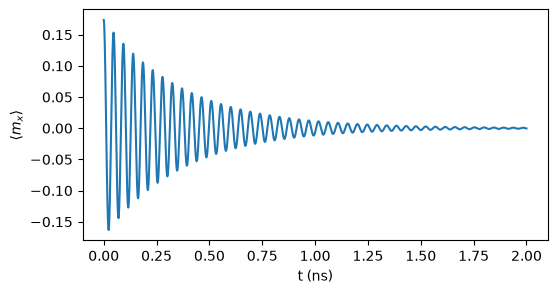

In [3]:
freqs = np.fft.rfftfreq(n_steps, p.dt)
spectrum = np.abs(np.fft.rfft(mx - mx.mean()))
f_sim = freqs[np.argmax(spectrum)]
f_kittel = p.gamma / (2 * np.pi) * (B + 2 * K_eff / Ms)
print(f'f simulated = {f_sim/1e9:.2f} GHz, Kittel = {f_kittel/1e9:.2f} GHz')
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(times * 1e9, mx)
ax.set_xlabel('t (ns)')
ax.set_ylabel('$\\langle m_x \\rangle$')
plt.show()

## Current-driven skyrmion

Relax a skyrmion, then drive it with a constant current of $10^{12}$ A/m$^2$. The drive is the `pulse` parameter, evaluated at every substage time.

In [4]:
A_ex, D, K_eff, Ms = 16.0e-12, 3.0e-3, 510.0e3, 8.755e5
a, nx = 1.0e-9, 64
K = K_eff + 0.5 * mu0 * Ms**2
p = make_params(nx=nx, ny=nx, a=a, A_ex=A_ex, D=D, K_top=K, K_bot=K,
                Ms=Ms, alpha=0.3, H_RKKY=0.0, H_ext=np.zeros(3),
                dt=5.0e-14, pulse=ConstantPulse(0.0))
m0 = skyrmion_profile(nx, nx, a=a, R=10.0e-9, dw=5.6e-9, polarity=+1)
m, _, converged, _, _, _ = relax(m0, None, p, None, max_steps=100000,
                                 tol_torque=1.0e-4, check_every=500)
print(f'relaxed: converged={converged}')

relaxed: converged=True


In [5]:
p.pulse = ConstantPulse(1.0e12)
n_steps, sample_every = 20000, 500
centers = []
for i in range(n_steps):
    m = rk4_step_single(rhs, m, i * p.dt, p.dt, p)
    if i % sample_every == 0:
        centers.append(skyrmion_center_pbc(m, a, +1))
centers = np.array(centers)
# Unwrap the periodic box so the trajectory is continuous.
box = nx * a
centers = np.unwrap(centers / box * 2 * np.pi, axis=0) * box / (2 * np.pi)
disp = centers[-1] - centers[0]
t_drive = n_steps * p.dt
print(f'displacement = ({disp[0]*1e9:+.1f}, {disp[1]*1e9:+.1f}) nm '
      f'in {t_drive*1e9:.2f} ns')
print(f'speed = {np.linalg.norm(disp)/t_drive:.1f} m/s, '
      f'Hall angle = {np.degrees(np.arctan2(disp[1], disp[0])):.1f} deg')

displacement = (-10.9, -26.8) nm in 1.00 ns
speed = 28.9 m/s, Hall angle = -112.2 deg


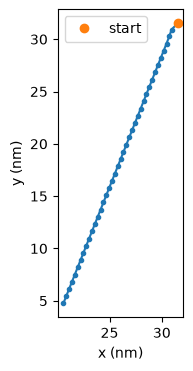

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot(centers[:, 0] * 1e9, centers[:, 1] * 1e9, '.-')
ax.plot(*(centers[0] * 1e9), 'o', label='start')
ax.set_xlabel('x (nm)')
ax.set_ylabel('y (nm)')
ax.set_aspect('equal')
ax.legend()
plt.show()